In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from math import factorial
from scipy import special
from scipy.sparse import diags, kronsum
from scipy.sparse.linalg import eigsh
from scipy.linalg import eigh_tridiagonal

pd.set_option("display.precision", 10)


# **Team 7: The Quantum Harmonic Oscillator Presentation**

# Brandon: 1D Finite-Difference Hamiltonian

This notebook calculates the approximate second derivative of the quantum harmonic oscillator and constructs a hamiltonian matrix:
Everything here is kept in **one spatial dimension**,
We use dimensionless units, $\hbar = m = \omega = 1$, so the Hamiltonian is
$$
H = -\frac{1}{2}\frac{d^2}{dx^2} + \frac{1}{2}x^2 ,
$$
and the known analytic energies are $E_n = n + \tfrac{1}{2}$. These are the
same conventions used throughout the project.

## Shared grid and parameter definitions

- Physical units: dimensionless, $\hbar = m = \omega = 1$
- Spatial interval: $x \in [-L, L]$ with $L = 8$
- Number of grid points: $N = 1000$, including the two boundary points
- Boundary condition: Dirichlet, $\psi(\pm L) = 0$
- Eigenstates: the lowest 6

In [2]:
# Dimensionless units
hbar = 1.0
mass = 1.0
omega = 1.0
# Shared numerical-box parameters
L = 8.0
N = 1000
num_states = 6
# Full grid, including the two boundary points
x_full = np.linspace(-L, L, N)
dx = x_full[1] - x_full[0]
# Dirichlet boundary conditions fix psi(-L) = psi(L) = 0, so only the interior points are unknowns in the eigenvalue problem.
x = x_full[1:-1]
M = x.size
print(f"Domain: [{-L}, {L}]")
print(f"Total grid points N: {N}")
print(f"Interior unknowns M: {M}")
print(f"Grid spacing dx: {dx:.6f}")

Domain: [-8.0, 8.0]
Total grid points N: 1000
Interior unknowns M: 998
Grid spacing dx: 0.016016


## Finite-difference second derivative

For an interior grid point $x_i$, the centered, second-order finite
difference approximation to the second derivative is
$$
\left.\frac{d^2\psi}{dx^2}\right|_{x_i} \approx
\frac{\psi_{i+1} - 2\psi_i + \psi_{i-1}}{\Delta x^2}.
$$

Applied at every interior point, this turns the derivative into a
tridiagonal matrix with $-2$ on the main diagonal and $1$ on the first
off-diagonals (before dividing by $\Delta x^2$).

To make the pattern easy to check by eye, we first build this matrix on a
tiny 6-point grid before using it at full resolution.

In [3]:
# Small demonstration grid
M_demo = 6
lower_demo = np.ones(M_demo - 1)
main_demo = -2.0 * np.ones(M_demo)
upper_demo = np.ones(M_demo - 1)
D2_demo = diags(
    [lower_demo, main_demo, upper_demo], [-1, 0, 1], shape=(M_demo, M_demo)
).toarray()
print("Unscaled second-derivative pattern (before dividing by dx^2):")
print(D2_demo)
assert D2_demo.shape == (M_demo, M_demo), "unexpected shape"
assert np.allclose(D2_demo, D2_demo.T), "pattern is not symmetric"
assert np.allclose(np.diag(D2_demo), -2.0), "main diagonal should be -2"
print("\nShape, symmetry, and diagonal value all check out.")

Unscaled second-derivative pattern (before dividing by dx^2):
[[-2.  1.  0.  0.  0.  0.]
 [ 1. -2.  1.  0.  0.  0.]
 [ 0.  1. -2.  1.  0.  0.]
 [ 0.  0.  1. -2.  1.  0.]
 [ 0.  0.  0.  1. -2.  1.]
 [ 0.  0.  0.  0.  1. -2.]]

Shape, symmetry, and diagonal value all check out.


In [4]:
# Full-resolution second-derivative matrix, stored as sparse CSR
lower = np.ones(M - 1)
main = -2.0 * np.ones(M)
upper = np.ones(M - 1)
D2 = diags(
    diagonals=[lower, main, upper],
    offsets=[-1, 0, 1],
    shape=(M, M),
    format="csr",
) / dx**2
print(f"D2 shape: {D2.shape}")
print(f"D2 symmetric to numerical precision: {abs(D2 - D2.T).max() < 1e-10}")
print(f"D2 stored nonzeros: {D2.nnz} (expected {3*M - 2})")

D2 shape: (998, 998)
D2 symmetric to numerical precision: True
D2 stored nonzeros: 2992 (expected 2992)


# Marc: 2D Hamiltonian allowed energy levels and wavefunctions

&emsp;This notebook seeks to explore the eigenvectors (and corresponding eigenvalues) associated with the Hamiltonian in two spatial dimensions. Note that this module utilizes the procedures discussed in the 1D case, developed by Brandon Blake. The procedure follows the same finite-difference approach as the 1D case. Dimensionless units are used here as well:
$$\hbar = m = \omega = 1$$
&emsp;Therefore, the 2D Hamiltonian is:
$$H = -\frac{1}{2}(\frac{\partial^2}{{\partial x}^2}+\frac{\partial^2}{{\partial y}^2})+\frac{1}{2}(x^2+y^2)$$

## Preparation

The conditions for this instance will remain (almost) intact with respect to the one-dimensional case:
- Physical units: dimensionless, $\hbar =m = \omega = 1$
- Spatial interval: $x,y \in [-L,L]$ with $L=8$
- Number of grid points: *$N=100$*, including the two boundary points
    - Number of grid points must be reduced to decrease memory demand as matrix dimensions grow as $N^2$
- Dirichlet boundary condition: $\psi(\pm L)=0$
- Requested eigenestates: lowest six


In [5]:
# Use separate names for the 2D grid so the 1D variables stay unchanged.
N_2d = 100

x_full_2d = np.linspace(-L, L, N_2d)
y_full_2d = np.linspace(-L, L, N_2d)

dx_2d = x_full_2d[1] - x_full_2d[0]
dy_2d = y_full_2d[1] - y_full_2d[0]

x_2d = x_full_2d[1:-1]
y_2d = y_full_2d[1:-1]
M_2d = x_2d.size


## Finite difference

&emsp;In 2D, the second derivative is expressed by the Laplacian operator $\nabla^2$, which is the sum of the second derivative in the x-direction and second derivative in the y-direction. Let the 2D grid have points denoted by the index pair $(i,j)$ for the x and y coordinates respectively. The second-order finite difference approximation is then:
$$\nabla^2 \psi {\vert}_{i,j}=(\frac{\partial^2}{\partial x^2}+\frac{\partial^2}{\partial y^2}) \approx \frac{{\psi}_{i+1,j}-2{\psi}_{i,j}+{\psi}_{i-1,j}}{\Delta x^2}+\frac{{\psi}_{i,j+1}-2{\psi}_{i,j}+{\psi}_{i,j-1}}{\Delta y^2}$$

&emsp;Since $\Delta x = \Delta y$, we may simplify the expression and produce the following:
$$\nabla^2 \psi {\vert}_{i,j}=(\frac{\partial^2}{\partial x^2}+\frac{\partial^2}{\partial y^2}) \approx \frac{{\psi}_{i+1,j}+{\psi}_{i-1,j}+{\psi}_{i,j+1}+{\psi}_{i,j-1}-4{\psi}_{i,j}}{\Delta x^2}$$

&emsp;Applying this procedure produces a matrix that is not tridiagonal in the usual 1D sense. Given that we must flatten the M matrix into a vector (of length $M^2$) to produce the Hamiltonian matrix. When calculating the laplacian for a particular point, we take the points around it (above, below, left, and right). To get to the point directly above or below in the matrix, M spaces in the vector must be traversed. This process of translation between spaces places ones along the off-diagonals that are located M rows below the original diagonal in the Hamiltonian matrix; it also gives ones along the immediate off-diagonals. This behavior is captured and expressed by the `scipy.sparse.kronsum` instance.  

&emsp;As in the 1D case, a small 3-by-3 grid is used first before applying the method to the larger grid.

In [6]:
M_demo_2d = 3

main_demo_2d = -2.0 * np.ones(M_demo_2d)
lower_demo_2d = np.ones(M_demo_2d - 1)
upper_demo_2d = np.ones(M_demo_2d - 1)

D2_x_demo = diags(
    [lower_demo_2d, main_demo_2d, upper_demo_2d],
    [-1, 0, 1],
    shape=(M_demo_2d, M_demo_2d),
    format="csr",
) / dx_2d**2
D2_y_demo = diags(
    [lower_demo_2d, main_demo_2d, upper_demo_2d],
    [-1, 0, 1],
    shape=(M_demo_2d, M_demo_2d),
    format="csr",
) / dy_2d**2

D2_2D_demo = kronsum(D2_y_demo, D2_x_demo, format="csr")
print(D2_2D_demo.toarray())


[[-153.140625     38.28515625    0.           38.28515625    0.
     0.            0.            0.            0.        ]
 [  38.28515625 -153.140625     38.28515625    0.           38.28515625
     0.            0.            0.            0.        ]
 [   0.           38.28515625 -153.140625      0.            0.
    38.28515625    0.            0.            0.        ]
 [  38.28515625    0.            0.         -153.140625     38.28515625
     0.           38.28515625    0.            0.        ]
 [   0.           38.28515625    0.           38.28515625 -153.140625
    38.28515625    0.           38.28515625    0.        ]
 [   0.            0.           38.28515625    0.           38.28515625
  -153.140625      0.            0.           38.28515625]
 [   0.            0.            0.           38.28515625    0.
     0.         -153.140625     38.28515625    0.        ]
 [   0.            0.            0.            0.           38.28515625
     0.           38.28515625 -153.14

To visualize the array, a heatmap is employed.

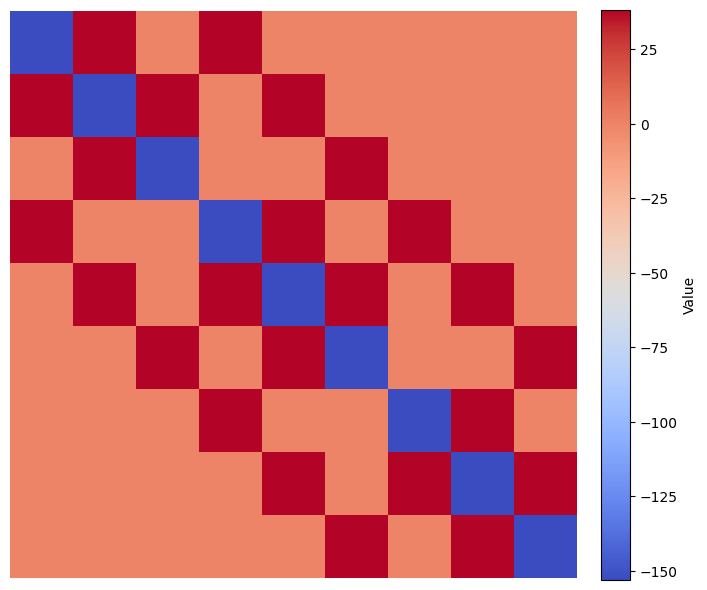

In [7]:
plt.figure(figsize=(8, 8))

d_matrix = D2_2D_demo.toarray() if hasattr(D2_2D_demo, 'toarray') else D2_2D_demo
plt.imshow(d_matrix, cmap='coolwarm', interpolation='nearest')
plt.axis('off') 
plt.grid(False)
plt.colorbar(label="Value", fraction=0.046, pad=0.04)
plt.show()

&emsp;The produced array is already scaled.
Notice the difference with respect to the array generated for the 1D case. The immediate off-diagonals are not lines of uninterrupted non-zero entries, and there are additional diagonal lines with all non-zero entries. 
We may proceed to create a bigger array (with $N=100$).

In [8]:
main_2d = -2.0 * np.ones(M_2d)
lower_2d = np.ones(M_2d - 1)
upper_2d = np.ones(M_2d - 1)

D2_x = diags(
    [lower_2d, main_2d, upper_2d],
    [-1, 0, 1],
    shape=(M_2d, M_2d),
    format="csr",
) / dx_2d**2
D2_y = diags(
    [lower_2d, main_2d, upper_2d],
    [-1, 0, 1],
    shape=(M_2d, M_2d),
    format="csr",
) / dy_2d**2

D2_2D = kronsum(D2_y, D2_x, format="csr")


Creating the potential grid.

In [9]:
X, Y = np.meshgrid(x_2d, y_2d)
V_2D = 0.5 * mass * omega**2 * (X**2 + Y**2)
V_diag = diags(V_2D.ravel(), offsets=0, format="csr")


## The Hamiltonian Matrix

&emsp;With the potential grid constructed, we can form the Hamiltonian Matrix by adding the potential matrix to the D matrix.

In [10]:
H_2D = -0.5 * (hbar**2 / mass) * D2_2D + V_diag

Obtaining the allowed energy levels. In this, we will use `scipy.sparse.linalg.eigsh` with the same `k=num_states` and `which="SA"` arguments. The reasons for these selections have been detailed in the 1D case. 

In [11]:
energies_2d, states_2d = eigsh(H_2D, k=num_states, which="SA")
order_2d = np.argsort(energies_2d)
energies_2d = energies_2d[order_2d]
states_2d = states_2d[:, order_2d]

# Normalize on the 2D grid.
for j in range(num_states):
    norm_2d = np.sqrt(np.sum(np.abs(states_2d[:, j])**2) * dx_2d * dy_2d)
    states_2d[:, j] /= norm_2d

for j in range(num_states):
    print(f"E_{j} = {energies_2d[j]:.10f}")


E_0 = 0.9983648354
E_1 = 1.9950891099
E_2 = 1.9950891099
E_3 = 2.9885240673
E_4 = 2.9885240673
E_5 = 2.9918133844


As a sanity check, compare the low-energy results with shift-invert mode on the same sparse Hamiltonian.


In [12]:
energies_ref = eigsh(
    H_2D.tocsc(),
    k=num_states,
    sigma=0.0,
    which="LM",
    return_eigenvectors=False,
)
energies_ref = np.sort(energies_ref)
solver_difference = np.abs(energies_2d - energies_ref).max()
print(f"Largest direct vs shift-invert difference: {solver_difference:.3e}")
assert solver_difference < 1e-9, "the two solver modes disagree"

overlap_2d = states_2d.T.conj() @ states_2d * dx_2d * dy_2d
max_norm_error_2d = np.max(np.abs(np.diag(overlap_2d) - 1.0))
max_orth_error_2d = np.max(np.abs(overlap_2d - np.eye(num_states)))
print(f"Maximum normalization error: {max_norm_error_2d:.3e}")
print(f"Maximum orthogonality error: {max_orth_error_2d:.3e}")


Largest direct vs shift-invert difference: 5.196e-14
Maximum normalization error: 4.441e-16
Maximum orthogonality error: 1.506e-15


## Visualizing the discrepancies

&emsp; In this case, the energies are given by 
$$E_{n_x,n_y}=n_x + n_y + 1, \qquad n=0,1,2,3,...$$
with the table below giving the numerical and analytical values, as well as the absolute ($|E_n^{num}-E_n|$) and relative differences (as a percentage). 

In [13]:
n = np.arange(num_states)
nx, ny = np.meshgrid(n,n)
energies = nx +ny + 1.0
energies_exact = np.sort(energies.flatten())[:num_states]
absolute_difference = np.abs(energies_2d - energies_exact)
relative_difference_percent = 100.0 * absolute_difference / energies_exact

comparison = pd.DataFrame({
    "n": n,
    "Numerical energy": energies_2d,
    "Analytic energy": energies_exact,
    "Absolute difference": absolute_difference,
    "Relative difference (%)": relative_difference_percent,
})
comparison

,n,Numerical energy,Analytic energy,Absolute difference,Relative difference (%)
0,0,0.9983648354,1.0,0.0016351646,0.1635164640
1,1,1.9950891099,2.0,0.0049108901,0.2455445054
2,2,1.9950891099,2.0,0.0049108901,0.2455445054
3,3,2.9885240673,3.0,0.0114759327,0.3825310885
4,4,2.9885240673,3.0,0.0114759327,0.3825310885
5,5,2.9918133844,3.0,0.0081866156,0.2728871859


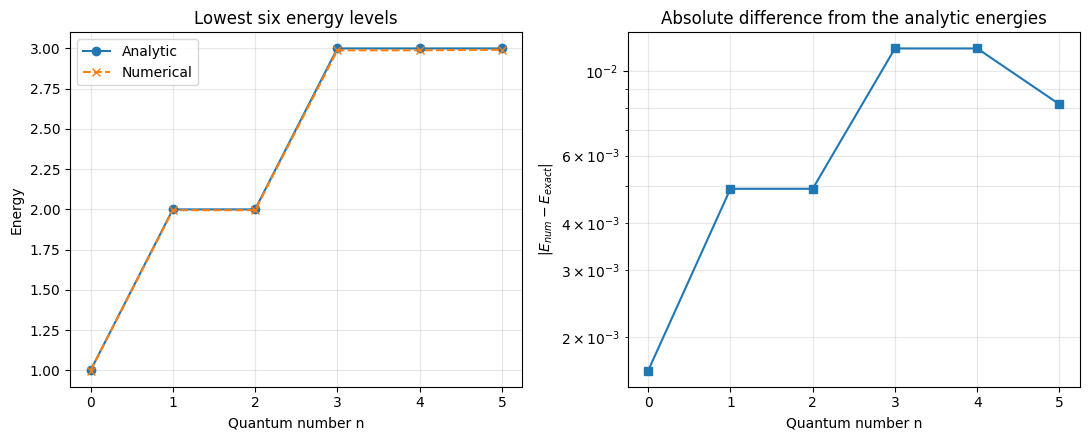

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(n, energies_exact, "o-", label="Analytic")
axes[0].plot(n, energies_2d, "x--", label="Numerical")
axes[0].set_xlabel("Quantum number n")
axes[0].set_ylabel("Energy")
axes[0].set_title("Lowest six energy levels")
axes[0].set_xticks(n)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].semilogy(n, absolute_difference, "s-")
axes[1].set_xlabel("Quantum number n")
axes[1].set_ylabel(r"$|E_{num} - E_{exact}|$")
axes[1].set_title("Absolute difference from the analytic energies")
axes[1].set_xticks(n)
axes[1].grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.show()

## Result

&emsp;For the 2d case, the six lowest numerical energy levels produce approximations with an error of at most $11.5\times10^{-3}$ with respect to the exact energy levels $E_n = n_x +n_y+1$. The relative maximum difference is about 0.38%. The two methods produce results that agree with each other to approximately $5.4\times10^{-14}$. As observed in the 1D case:
- The numerical values are lower than the analytical values due to the underestimation of the curvature of the wavefunction (and consequently the kinetic energy).
- The discrepancy (in general) increases with n as the oscillations become faster and wider, making the finite size of the box more noticeable. 

&emsp; Both of these effects - as discussed for the 1D case, should decrease as the grid spacing is decreased by the square of the grid spacing. Additionally, the box size $L$ also contributes to the mitigation of the discrepancies.

(Special recognition to the work of Brandon Blake as it was foundational for this module).

# Keunmo: Numerical energy comparison

Using the 1D finite-difference Hamiltonian, I calculated the lowest six energy levels and compared them with the exact harmonic-oscillator values,
\[
E_n=n+\frac{1}{2}.
\]

## Setup

I kept the same 1D settings used earlier: dimensionless units, \(x\in[-8,8]\), \(N=1000\), and Dirichlet boundary conditions. The second derivative is approximated with the centered finite-difference formula.

## Solver

I used `scipy.sparse.linalg.eigsh` because the Hamiltonian is symmetric and sparse, and only the lowest six states are needed. `which="SA"` returns the smallest algebraic eigenvalues.

In [15]:
# Rebuild the 1D Hamiltonian with separate variables.
L_k = 8.0
N_k = 1000
num_states_k = 6

x_full_k = np.linspace(-L_k, L_k, N_k)
dx_k = x_full_k[1] - x_full_k[0]
x_k = x_full_k[1:-1]
M_k = x_k.size

D2_k = diags(
    [np.ones(M_k - 1), -2.0 * np.ones(M_k), np.ones(M_k - 1)],
    [-1, 0, 1],
    shape=(M_k, M_k),
    format="csr",
) / dx_k**2

V_k = 0.5 * x_k**2
H_k = -0.5 * D2_k + diags(V_k, 0, format="csr")

energies_num_k, states_k = eigsh(H_k, k=num_states_k, which="SA")
order_k = np.argsort(energies_num_k)
energies_num_k = energies_num_k[order_k]
states_k = states_k[:, order_k]

for j in range(num_states_k):
    norm_k = np.sqrt(np.trapezoid(np.abs(states_k[:, j])**2, x_k))
    states_k[:, j] /= norm_k

energies_num_k


array([0.49999198, 1.49995992, 2.49989579, 3.49979959, 4.49967132,
       5.49951098])

In [16]:
n_k = np.arange(num_states_k)
energies_exact_k = n_k + 0.5
absolute_difference_k = np.abs(energies_num_k - energies_exact_k)
relative_difference_percent_k = 100.0 * absolute_difference_k / energies_exact_k

comparison_k = pd.DataFrame({
    "n": n_k,
    "Numerical energy": energies_num_k,
    "Analytic energy": energies_exact_k,
    "Absolute difference": absolute_difference_k,
    "Relative difference (%)": relative_difference_percent_k,
})

comparison_k


,n,Numerical energy,Analytic energy,Absolute difference,Relative difference (%)
0,0,0.4999919838,0.5,0.0000080162,0.0016032306
1,1,1.4999599187,1.5,0.0000400813,0.0026720851
2,2,2.4998957872,2.5,0.0001042128,0.0041685124
3,3,3.4997995877,3.5,0.0002004123,0.0057260656
4,4,4.4996713187,4.5,0.0003286813,0.0073040284
5,5,5.4995109787,5.5,0.0004890213,0.0088912963


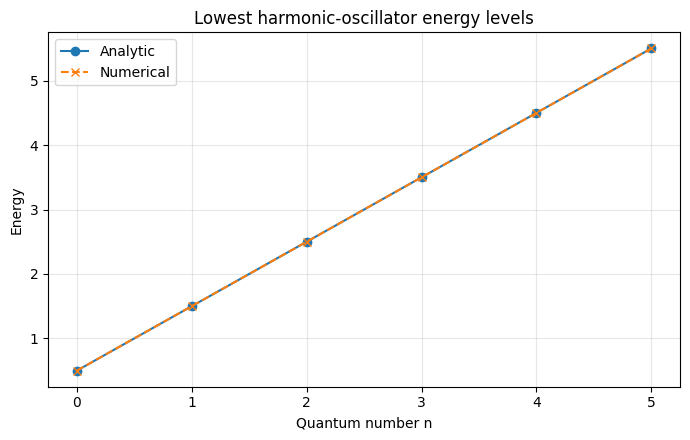

In [17]:
plt.figure(figsize=(7, 4.5))
plt.plot(n_k, energies_exact_k, "o-", label="Analytic")
plt.plot(n_k, energies_num_k, "x--", label="Numerical")
plt.xlabel("Quantum number n")
plt.ylabel("Energy")
plt.title("Lowest harmonic-oscillator energy levels")
plt.xticks(n_k)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [18]:
overlap_k = states_k.T.conj() @ states_k * dx_k
max_normalization_error_k = np.max(np.abs(np.diag(overlap_k) - 1.0))
max_orthogonality_error_k = np.max(
    np.abs(overlap_k - np.eye(num_states_k))
)

print(f"Maximum normalization error: {max_normalization_error_k:.3e}")
print(f"Maximum orthogonality error: {max_orthogonality_error_k:.3e}")
print(f"Largest absolute energy difference: {absolute_difference_k.max():.3e}")


Maximum normalization error: 2.331e-14
Maximum orthogonality error: 2.331e-14
Largest absolute energy difference: 4.890e-04


## Result

The numerical energies agree closely with the exact values. The small remaining difference comes from the finite grid spacing and the finite box size. Those effects are checked separately in the convergence sections.

# Ryan: Grid-Spacing Convergence and Solver Cost

This section checks two items from the checkpoint feedback:

- how the energy error behaves as the grid is refined at **fixed box size**, and
- how matrix size, solver settings, and runtime scale with the number of grid points.

The **box-size** study is deliberately not included here. That test holds the grid
spacing fixed and moves the boundaries instead, and it is being handled separately;
mixing the two sweeps in one loop is exactly what makes the two error sources
impossible to separate.

All conventions match `qho_1d_hamiltonian.ipynb`: dimensionless units
$\hbar = m = \omega = 1$, the interval $x \in [-L, L]$, Dirichlet boundary conditions
$\psi(\pm L) = 0$, a centered second-order finite difference, sparse CSR storage, and
the lowest 6 states. The analytic energies are $E_n = n + \tfrac{1}{2}$.

## Shared construction

Both studies call the same two helpers, so every row below comes from an identical
discretization. Only $N$ changes in this notebook; $L$ is held at 8 throughout.

In [19]:
hbar = 1.0
mass = 1.0
omega = 1.0
L = 8.0
num_states = 6
n = np.arange(num_states)
energies_exact = n + 0.5


def build_hamiltonian(L, N):
    x_full = np.linspace(-L, L, N)
    dx = x_full[1] - x_full[0]
    x = x_full[1:-1]
    M = x.size
    D2 = diags(
        diagonals=[np.ones(M - 1), -2.0 * np.ones(M), np.ones(M - 1)],
        offsets=[-1, 0, 1],
        shape=(M, M),
        format="csr",
    ) / dx**2
    V = 0.5 * mass * omega**2 * x**2
    H = -0.5 * (hbar**2 / mass) * D2 + diags(V, offsets=0, format="csr")
    return x, dx, M, H


def solve(L, N, num_states=num_states):
    x, dx, M, H = build_hamiltonian(L, N)
    energies, states = eigsh(H, k=num_states, which="SA")
    order = np.argsort(energies)
    energies = energies[order]
    states = states[:, order]
    for j in range(num_states):
        states[:, j] /= np.sqrt(np.trapezoid(np.abs(states[:, j])**2, x))
    return {"x": x, "dx": dx, "M": M, "nnz": H.nnz, "energies": energies, "states": states}

In [20]:
baseline = solve(L, 1000)
baseline_error = np.abs(baseline["energies"] - energies_exact)
print(f"dx at N = 1000: {baseline['dx']:.10f}")
print(f"E_0: {baseline['energies'][0]:.10f}")
print(f"E_5: {baseline['energies'][5]:.10f}")
assert np.allclose(baseline["energies"], [0.4999919838, 1.4999599187, 2.4998957872,
                                          3.4997995877, 4.4996713187, 5.4995109787], atol=1e-9)
print("Baseline reproduces the energies from qho_1d_hamiltonian.ipynb.")

dx at N = 1000: 0.0160160160
E_0: 0.4999919838
E_5: 5.4995109787
Baseline reproduces the energies from qho_1d_hamiltonian.ipynb.


## Grid-spacing study

The physical box is fixed at $x \in [-8, 8]$ and only the number of grid points is
increased, so $\Delta x = 2L/(N-1)$ shrinks while the boundaries stay put. Any change
in the energies is therefore a discretization effect and not a box effect.

In [21]:
N_values = [200, 400, 800, 1600, 3200, 6400]
rows = []
grid_errors = []
for N in N_values:
    result = solve(L, N)
    error = np.abs(result["energies"] - energies_exact)
    grid_errors.append(error)
    rows.append({"N": N, "M": result["M"], "dx": result["dx"],
                 **{f"|dE_{j}|": error[j] for j in range(num_states)}})
grid_errors = np.array(grid_errors)
dx_values = np.array([r["dx"] for r in rows])

grid_study = pd.DataFrame(rows)
grid_study

,N,M,dx,|dE_0|,|dE_1|,|dE_2|,|dE_3|,|dE_4|,|dE_5|
0,200,198,0.0804020101,0.0002020968,0.0010108116,0.0026290613,0.0050578333,0.0082981191,0.0123509142
1,400,398,0.0401002506,0.0000502560,0.0002513002,0.0006534391,0.0012567335,0.0020612442,0.0030670320
2,800,798,0.0200250313,0.0000125316,0.0000626594,0.0001629180,0.0003133113,0.0005138430,0.0007645170
3,1600,1598,0.0100062539,0.0000031289,0.0000156447,0.0000406765,0.0000782245,0.0001282890,0.0001908702
4,3200,3198,0.0050015630,0.0000007817,0.0000039087,0.0000101626,0.0000195436,0.0000320515,0.0000476865
5,6400,6398,0.0025003907,0.0000001954,0.0000009769,0.0000025399,0.0000048844,0.0000080103,0.0000119178


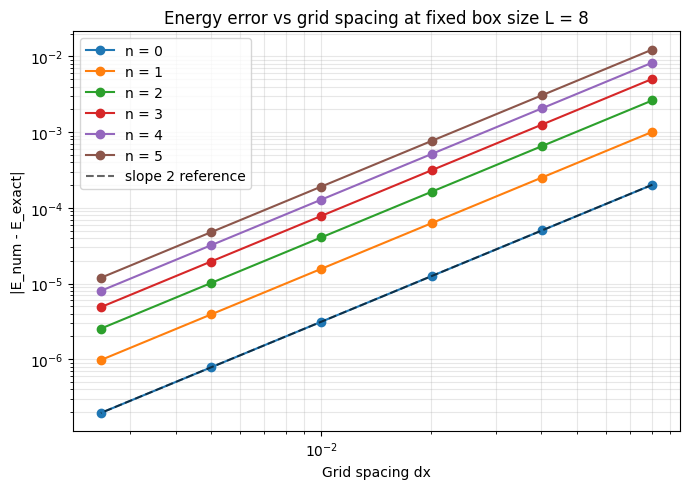

In [22]:
plt.figure(figsize=(7, 5))
for j in range(num_states):
    plt.loglog(dx_values, grid_errors[:, j], "o-", label=f"n = {j}")
plt.loglog(dx_values, grid_errors[0, 0] * (dx_values / dx_values[0])**2, "k--",
           alpha=0.6, label="slope 2 reference")
plt.xlabel("Grid spacing dx")
plt.ylabel("|E_num - E_exact|")
plt.title("Energy error vs grid spacing at fixed box size L = 8")
plt.grid(True, alpha=0.3, which="both")
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
slopes = [np.polyfit(np.log(dx_values), np.log(grid_errors[:, j]), 1)[0] for j in range(num_states)]
convergence_order = pd.DataFrame({
    "n": n,
    "Fitted slope": slopes,
    "Error at dx = 0.0804": grid_errors[0],
    "Error at dx = 0.0025": grid_errors[-1],
    "Reduction factor": grid_errors[0] / grid_errors[-1],
})
convergence_order

,n,Fitted slope,Error at dx = 0.0804,Error at dx = 0.0025,Reduction factor
0,0,2.0000944137,0.0002020968,0.0000001954,1034.4036960291
1,1,2.0001740609,0.0010108116,0.0000009769,1034.7507089103
2,2,2.0002596984,0.0026290613,0.0000025399,1035.1226965855
3,3,2.0003505545,0.0050578333,0.0000048844,1035.5176076749
4,4,2.0004445080,0.0082981191,0.0000080103,1035.9266938342
5,5,2.0005396133,0.0123509142,0.0000119178,1036.3409620243


## Leading-order error model

The fitted slopes confirm the expected $O(\Delta x^2)$ behaviour, so the error should
be $|\Delta E_n| = C_n \Delta x^2$ for some constant depending on the state. Dividing
the measured errors by $\Delta x^2$ gives values that settle on
$\tfrac{1}{32}, \tfrac{5}{32}, \tfrac{13}{32}, \tfrac{25}{32}, \tfrac{41}{32}, \tfrac{61}{32}$,
whose numerators are $2n^2 + 2n + 1$. That suggests

$$
\Delta E_n \simeq -\frac{\Delta x^2}{32}\left(2n^2 + 2n + 1\right),
$$

with the minus sign because the finite difference understates the curvature and so
understates the kinetic energy. The table below tests this prediction, which has no
fitted parameters, against the measured errors.

In [24]:
predicted = np.outer(dx_values**2, (2 * n**2 + 2 * n + 1) / 32.0)
model_check = pd.DataFrame({"N": N_values, "dx": dx_values})
for j in range(num_states):
    model_check[f"ratio n={j}"] = grid_errors[:, j] / predicted[:, j]
model_check

,N,dx,ratio n=0,ratio n=1,ratio n=2,ratio n=3,ratio n=4,ratio n=5
0,200,0.0804020101,1.0004045208,1.0007287278,1.0010909128,1.0014762817,1.0018713885,1.0022716285
1,400,0.0401002506,1.0001005329,1.0001809947,1.0002707757,1.0003661727,1.0004638377,1.0005626238
2,800,0.0200250313,1.0000250682,1.0000451194,1.0000674870,1.0000912495,1.0001155664,1.0001401536
3,1600,0.0100062539,1.0000064257,1.0000112856,1.0000168404,1.0000227697,1.0000288517,1.0000349857
4,3200,0.0050015630,1.0000026845,1.0000025870,1.0000039048,1.0000056147,1.0000072052,1.0000087319
5,6400,0.0025003907,1.0000084033,0.9999970115,0.9999994369,1.0000028732,1.0000023430,1.0000019345


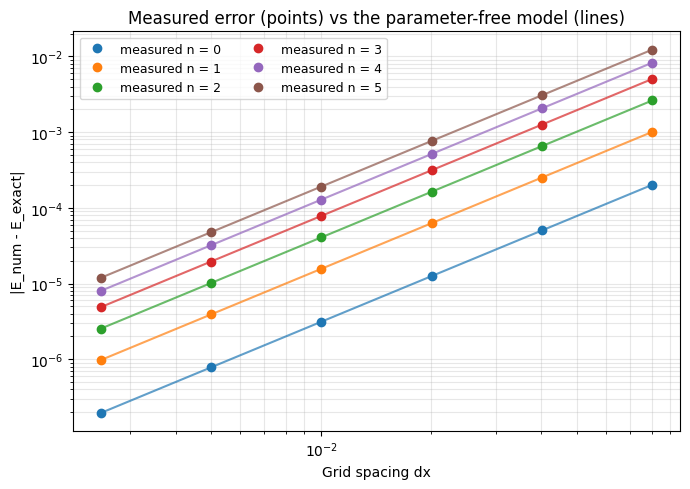

In [25]:
plt.figure(figsize=(7, 5))
for j in range(num_states):
    plt.loglog(dx_values, grid_errors[:, j], "o", label=f"measured n = {j}")
plt.gca().set_prop_cycle(None)
for j in range(num_states):
    plt.loglog(dx_values, predicted[:, j], "-", alpha=0.7)
plt.xlabel("Grid spacing dx")
plt.ylabel("|E_num - E_exact|")
plt.title("Measured error (points) vs the parameter-free model (lines)")
plt.grid(True, alpha=0.3, which="both")
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

## Matrix size, solver settings, and runtime

The same Hamiltonians are now solved with four different configurations:

| Label | Call | Notes |
| --- | --- | --- |
| `eigsh SA` | `eigsh(H, k=6, which="SA")` | Lanczos on the sparse matrix, lowest algebraic eigenvalues |
| `eigsh shift-invert` | `eigsh(H, k=6, sigma=0.0, which="LM")` | Lanczos on $(H - \sigma I)^{-1}$, which clusters the wanted states at the top of the transformed spectrum |
| `eigh_tridiagonal` | `eigh_tridiagonal(d, e, select="i", select_range=(0, 5))` | direct LAPACK solver for the tridiagonal form |
| `dense eigh` | `np.linalg.eigh(H.toarray())` | full spectrum of the dense matrix, run only up to $M \approx 2000$ |

Each timing is the best of a few repeats. Memory columns compare the stored sparse
entries with the $M^2$ doubles a dense copy would require.

In [26]:
def best_time(call, repeats=3):
    times = []
    for _ in range(repeats):
        start = time.perf_counter()
        call()
        times.append(time.perf_counter() - start)
    return min(times)


timing_rows = []
for N in N_values:
    x, dx, M, H = build_hamiltonian(L, N)
    H_csc = H.tocsc()
    diag_ref = hbar**2 / (mass * dx**2) + 0.5 * mass * omega**2 * x**2
    offdiag_ref = -0.5 * (hbar**2 / mass) * np.ones(M - 1) / dx**2
    repeats = 3 if M <= 3200 else 1
    t_sa = best_time(lambda: eigsh(H, k=num_states, which="SA"), repeats)
    t_si = best_time(lambda: eigsh(H_csc, k=num_states, sigma=0.0, which="LM"), 3)
    t_tri = best_time(lambda: eigh_tridiagonal(diag_ref, offdiag_ref, eigvals_only=True,
                                               select="i", select_range=(0, num_states - 1)), 3)
    if M <= 2000:
        H_dense = H.toarray()
        t_dense = best_time(lambda: np.linalg.eigh(H_dense), 2)
    else:
        t_dense = np.nan
    sparse_mb = (H.data.nbytes + H.indices.nbytes + H.indptr.nbytes) / 1e6
    timing_rows.append({"N": N, "M": M, "nnz": H.nnz, "Sparse MB": sparse_mb,
                        "Dense MB": M * M * 8 / 1e6, "eigsh SA (s)": t_sa,
                        "eigsh shift-invert (s)": t_si, "eigh_tridiagonal (s)": t_tri,
                        "dense eigh (s)": t_dense})

cost = pd.DataFrame(timing_rows)
pd.set_option("display.precision", 5)
cost

,N,M,nnz,Sparse MB,Dense MB,eigsh SA (s),eigsh shift-invert (s),eigh_tridiagonal (s),dense eigh (s)
0,200,198,592,0.0079,0.31363,0.00504,0.00088,0.00032,0.00318
1,400,398,1192,0.0159,1.26723,0.01872,0.00196,0.00071,0.01384
2,800,798,2392,0.0319,5.09443,0.08205,0.00250,0.00123,0.10276
3,1600,1598,4792,0.0639,20.42883,0.22454,0.00405,0.00261,0.52870
4,3200,3198,9592,0.1279,81.81763,1.93976,0.00654,0.00462,NaN
5,6400,6398,19192,0.2559,327.47523,12.64933,0.01294,0.00921,NaN


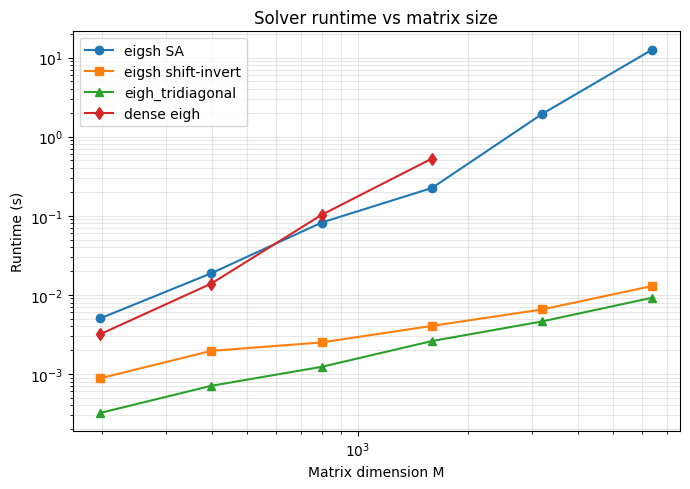

In [27]:
plt.figure(figsize=(7, 5))
M_values = cost["M"].to_numpy()
for column, marker in [("eigsh SA (s)", "o-"), ("eigsh shift-invert (s)", "s-"),
                       ("eigh_tridiagonal (s)", "^-"), ("dense eigh (s)", "d-")]:
    plt.loglog(M_values, cost[column], marker, label=column.replace(" (s)", ""))
plt.xlabel("Matrix dimension M")
plt.ylabel("Runtime (s)")
plt.title("Solver runtime vs matrix size")
plt.grid(True, alpha=0.3, which="both")
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
scaling = pd.DataFrame({
    "Solver": ["eigsh SA", "eigsh shift-invert", "eigh_tridiagonal", "dense eigh"],
    "Fitted exponent p in t ~ M^p": [
        np.polyfit(np.log(M_values), np.log(cost["eigsh SA (s)"]), 1)[0],
        np.polyfit(np.log(M_values), np.log(cost["eigsh shift-invert (s)"]), 1)[0],
        np.polyfit(np.log(M_values), np.log(cost["eigh_tridiagonal (s)"]), 1)[0],
        np.polyfit(np.log(M_values[:4]), np.log(cost["dense eigh (s)"][:4]), 1)[0],
    ],
})
scaling

,Solver,Fitted exponent p in t ~ M^p
0,eigsh SA,2.22266
1,eigsh shift-invert,0.72118
2,eigh_tridiagonal,0.95226
3,dense eigh,2.49171


In [29]:
x_ref, dx_ref, M_ref, H_ref = build_hamiltonian(L, 3200)
energies_sa = np.sort(eigsh(H_ref, k=num_states, which="SA")[0])
energies_si = np.sort(eigsh(H_ref.tocsc(), k=num_states, sigma=0.0, which="LM")[0])
diag_ref = hbar**2 / (mass * dx_ref**2) + 0.5 * mass * omega**2 * x_ref**2
offdiag_ref = -0.5 * (hbar**2 / mass) * np.ones(M_ref - 1) / dx_ref**2
energies_tri = eigh_tridiagonal(diag_ref, offdiag_ref, eigvals_only=True,
                                select="i", select_range=(0, num_states - 1))
print(f"SA vs shift-invert: {np.abs(energies_sa - energies_si).max():.3e}")
print(f"SA vs eigh_tridiagonal: {np.abs(energies_sa - energies_tri).max():.3e}")
assert np.abs(energies_sa - energies_si).max() < 1e-9
assert np.abs(energies_sa - energies_tri).max() < 1e-9
print("All three solvers agree to well within the discretization error.")

SA vs shift-invert: 1.174e-12
SA vs eigh_tridiagonal: 5.628e-12
All three solvers agree to well within the discretization error.


## Results

**Convergence.** With the box fixed at $L = 8$, the fitted slopes of $\log|\Delta E_n|$
against $\log \Delta x$ are 2.00 for every state, and shrinking $\Delta x$ by a factor
of 32 shrinks the error by roughly $32^2 \approx 1000$. This is the expected
second-order behaviour of the centered difference, measured rather than assumed.

**Error model.** The measured errors match
$|\Delta E_n| = \tfrac{\Delta x^2}{32}(2n^2 + 2n + 1)$ to within a fraction of a
percent at the finer grids, with the agreement improving as $\Delta x$ shrinks and the
neglected higher-order terms die away. The error grows quadratically with the state
index, so the highest state requested sets the grid requirement.

**Cost.** The sparse storage stays negligible while a dense copy grows quadratically:
at $M \approx 6400$ the matrix holds about 19 000 nonzeros, roughly 0.26 MB, against
about 328 MB dense. Runtime tells a more interesting story than the memory does.
`eigsh` with `which="SA"` is the slowest option at large $M$, because the low-lying
eigenvalues of this operator are tightly clustered relative to the spectral range and
plain Lanczos converges slowly there. Both `sigma=0.0` shift-invert and the direct
`eigh_tridiagonal` are orders of magnitude faster at the same accuracy, and all three
agree on the eigenvalues. The fitted exponents are empirical over this range of $M$ rather than asymptotic values: at these sizes the fast solvers are partly dominated by call overhead, and the dense routine has not yet reached its eventual $O(M^3)$ regime.

**Consequence for the solver choice.** The sparse-solver argument still holds against
the dense route, but the specific setting matters: for this 1D tridiagonal Hamiltonian
`which="SA"` is the wrong knob, and either shift-invert or the tridiagonal solver
should be preferred at fine grids. This is worth carrying back into the main notebook,
where the current runs use `which="SA"`.

# Anderson Mao: Numerical box-size convergence

This section checks how the finite box size affects the lowest six 1D harmonic-oscillator states while keeping the grid spacing fixed.

## Method

The exact oscillator extends over the full real line, but the numerical problem uses \(x\in[-L,L]\) with \(\psi(\pm L)=0\). To separate box-size error from grid-spacing error, I keep
\[
\Delta x=0.02
\]
fixed and increase \(L\). For each box size,
\[
N=\operatorname{round}(2L/\Delta x)+1.
\]

I compare each energy with the \(L=8\) result and also check the wavefunction amplitude at the first interior points near the boundaries.

In [30]:
box_half_widths = (2.5, 3.0, 3.5, 4.0, 5.0, 6.0, 7.0, 8.0)
box_target_dx = 0.02
box_num_states = 6
box_exact = np.arange(box_num_states) + 0.5

box_results = {}
for L_box in box_half_widths:
    N_box = int(round(2 * L_box / box_target_dx)) + 1
    box_results[L_box] = solve(L_box, N_box, num_states=box_num_states)

box_reference_energies = box_results[8.0]["energies"]

box_rows = []
for L_box in box_half_widths:
    result = box_results[L_box]
    energies_box = result["energies"]
    states_box = result["states"]
    near_boundary = np.maximum(np.abs(states_box[0, :]), np.abs(states_box[-1, :]))

    row = {
        "L": L_box,
        "N": int(round(2 * L_box / box_target_dx)) + 1,
        "dx": result["dx"],
        "max_change_from_largest_box": np.max(np.abs(energies_box - box_reference_energies)),
        "max_near_boundary_amplitude": np.max(near_boundary),
    }
    for state in range(box_num_states):
        row[f"energy_{state}"] = energies_box[state]
        row[f"absolute_error_{state}"] = abs(energies_box[state] - box_exact[state])
        row[f"change_from_largest_box_{state}"] = abs(
            energies_box[state] - box_reference_energies[state]
        )
        row[f"near_boundary_amplitude_{state}"] = near_boundary[state]
    box_rows.append(row)

box_study = pd.DataFrame(box_rows)

box_study[[
    "L",
    "N",
    "dx",
    "max_change_from_largest_box",
    "max_near_boundary_amplitude",
]]

,L,N,dx,max_change_from_largest_box,max_near_boundary_amplitude
0,2.5,251,0.02,2.65080e+00,4.38343e-02
1,3.0,301,0.02,9.72404e-01,2.96241e-02
2,3.5,351,0.02,2.58424e-01,1.79756e-02
3,4.0,401,0.02,3.93766e-02,8.38904e-03
4,5.0,501,0.02,9.86524e-05,5.42304e-04
5,6.0,601,0.02,1.57648e-08,7.94172e-06
6,7.0,701,0.02,9.03277e-13,3.32506e-08
7,8.0,801,0.02,0.00000e+00,4.36822e-11


The \(n=5\) state is the widest of the six states, so it gives the strongest boundary test.

In [31]:
box_study[[
    "L",
    "energy_0",
    "energy_5",
    "absolute_error_5",
    "change_from_largest_box_5",
    "near_boundary_amplitude_5",
]]

,L,energy_0,energy_5,absolute_error_5,change_from_largest_box_5,near_boundary_amplitude_5
0,2.5,0.50494,8.15004,2.65004,2.65080e+00,4.38343e-02
1,3.0,0.50038,6.47164,0.97164,9.72404e-01,2.96241e-02
2,3.5,0.50001,5.75766,0.25766,2.58424e-01,1.79756e-02
3,4.0,0.49999,5.53861,0.03861,3.93766e-02,8.38904e-03
4,5.0,0.49999,5.49934,0.00066,9.86524e-05,5.42304e-04
5,6.0,0.49999,5.49924,0.00076,1.57648e-08,7.94172e-06
6,7.0,0.49999,5.49924,0.00076,4.06786e-13,3.32506e-08
7,8.0,0.49999,5.49924,0.00076,0.00000e+00,4.36822e-11


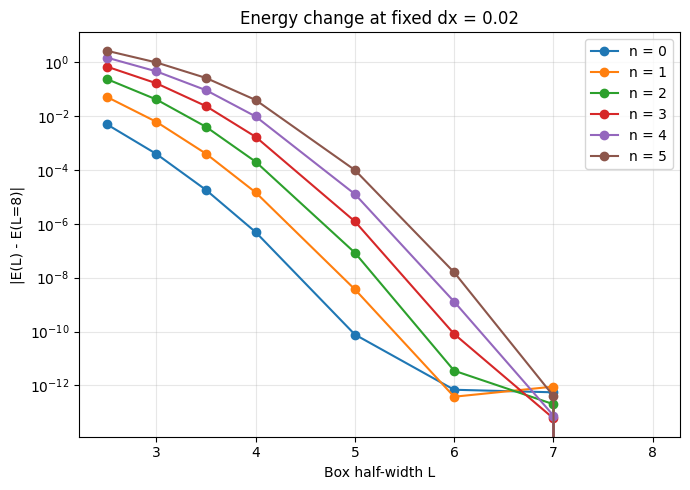

In [32]:
plt.figure(figsize=(7, 5))
for state in range(box_num_states):
    plt.semilogy(
        box_study["L"],
        box_study[f"change_from_largest_box_{state}"],
        "o-",
        label=f"n = {state}",
    )
plt.xlabel("Box half-width L")
plt.ylabel("|E(L) - E(L=8)|")
plt.title("Energy change at fixed dx = 0.02")
plt.grid(True, alpha=0.3, which="both")
plt.legend()
plt.tight_layout()
plt.show()

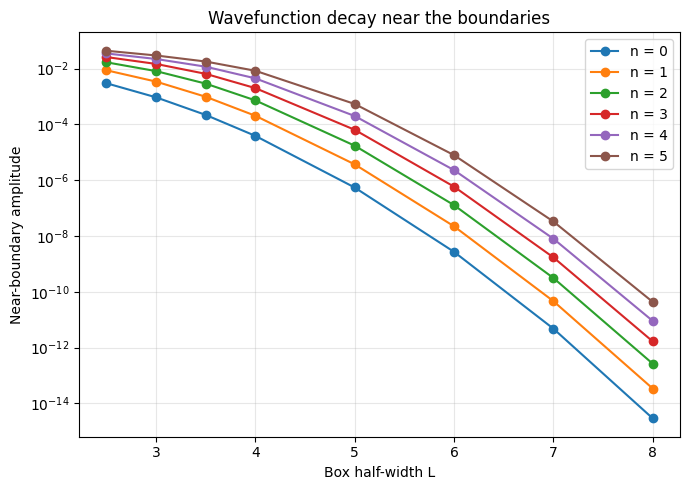

In [33]:
plt.figure(figsize=(7, 5))
for state in range(box_num_states):
    plt.semilogy(
        box_study["L"],
        box_study[f"near_boundary_amplitude_{state}"],
        "o-",
        label=f"n = {state}",
    )
plt.xlabel("Box half-width L")
plt.ylabel("Near-boundary amplitude")
plt.title("Wavefunction decay near the boundaries")
plt.grid(True, alpha=0.3, which="both")
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
box_energies = box_study[
    [f"energy_{state}" for state in range(box_num_states)]
].to_numpy()

index_l6 = int(np.flatnonzero(np.isclose(box_study["L"], 6.0))[0])
index_l7 = int(np.flatnonzero(np.isclose(box_study["L"], 7.0))[0])
index_l8 = int(np.flatnonzero(np.isclose(box_study["L"], 8.0))[0])

change_l6_l8 = np.max(np.abs(box_energies[index_l6] - box_energies[index_l8]))
change_l7_l8 = np.max(np.abs(box_energies[index_l7] - box_energies[index_l8]))
boundary_l8 = box_study.loc[index_l8, "max_near_boundary_amplitude"]

print(f"Maximum L=6 to L=8 energy change: {change_l6_l8:.3e}")
print(f"Maximum L=7 to L=8 energy change: {change_l7_l8:.3e}")
print(f"Largest near-boundary amplitude at L=8: {boundary_l8:.3e}")

assert np.ptp(box_study["dx"].to_numpy()) < 1e-12
assert change_l7_l8 < 1e-8
assert boundary_l8 < 1e-8

Maximum L=6 to L=8 energy change: 1.576e-08
Maximum L=7 to L=8 energy change: 9.033e-13
Largest near-boundary amplitude at L=8: 4.368e-11


## Result

Small boxes push the wider excited states away from their expected energies. At \(L=2.5\), the \(n=5\) energy is about \(8.15\), compared with the exact value \(5.5\). As \(L\) increases, both the energy change and the near-boundary amplitude drop quickly.

By \(L=7\) to \(L=8\), the largest energy change is already below \(10^{-8}\), and the boundary amplitude at \(L=8\) is also very small. This shows that \(L=8\) is large enough for the six states used here.

The remaining energy error does not go to zero in this test because \(\Delta x\) is held fixed. That remaining discretization error is checked in the grid-spacing study.

## References and assistance

- MIT OpenCourseWare, *Lecture 13: Delta Function Potential, Node Theorem, and Simple Harmonic Oscillator*.
- SciPy, `scipy.sparse.linalg.eigsh` documentation.
- Anderson's original notebook states that OpenAI Codex assisted with integrating the shared solver, implementing the convergence study, and drafting validation and explanatory text.

# Lizzie: Plots of Harmonic Oscillator Potential, First Few Wavefunctions, and Probability Density 

## The harmonic oscillator potential
Using the known potential term, we can construct the harmonic oscillator potential:
$$V(x) = \frac{1}{2} m \omega^2 x^2$$
across the spatial interval:
$x \in [-L, L]$ with $L = 8$

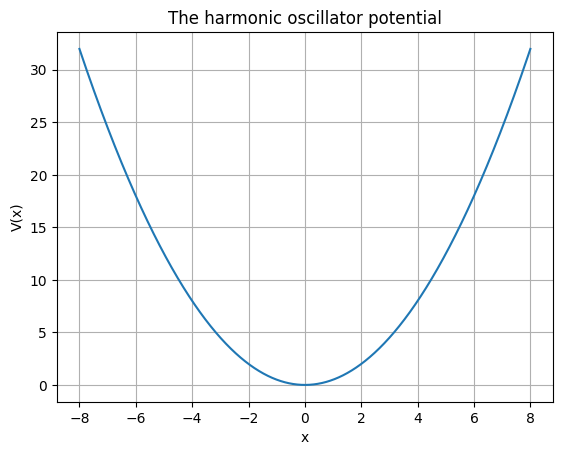

In [35]:
def potential():
    ## harmonic oscillator potential equation
    v = 0.5 * mass * omega**2 * x**2
    plt.plot(x, v)
    plt.xlabel('x')
    plt.ylabel('V(x)')
    plt.title('The harmonic oscillator potential')
    plt.grid(True)
    plt.show()

potential()

## First few wavefunctions
Using the known wavefunctions corresponding to the energies above:
$$ \psi_{n} = N_{n} e^(\frac{- \alpha}{2 \hbar}) H_{n} \sqrt{\alpha} x $$
where $$ \alpha = \frac{m \omega}{\hbar} $$
we can graph predictions of the wavefunctions for the numerical states.
<br>
The normalization constant $$ N_{n} = \frac{1}{\sqrt{2^n n!}} \left(\frac{\alpha}{\pi}\right)^{\frac{1}{4}} $$
and using `special.hermite()` for the hermite polynomial $$ H_{n} $$

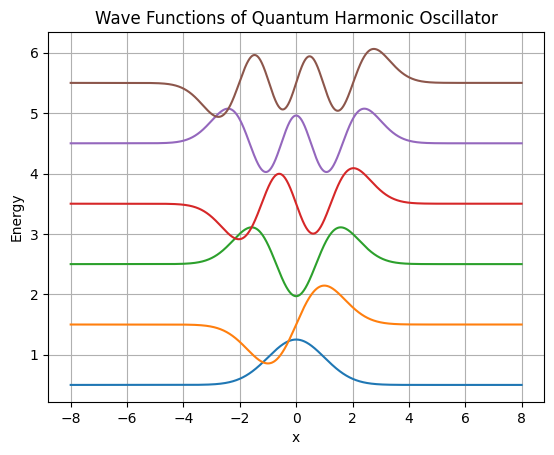

In [36]:
def psi(n, x):
    alpha = mass * omega / hbar
    norm = 1 / np.sqrt(2**n * factorial(n)) * (alpha / np.pi)**0.25
    H_n = special.hermite(n)
    return norm * np.exp(-alpha * x**2 / 2) * H_n(np.sqrt(alpha) * x)

for n_state in range(num_states):
    plt.plot(x, psi(n_state, x) + n_state + 0.5)

plt.title("Wave Functions of Quantum Harmonic Oscillator")
plt.xlabel("x")
plt.ylabel("Energy")
plt.grid(True)
plt.show()


## Probability Density
The probabilty density of the quantum harmonic oscillator is $$ |\psi_{n}|^2 $$.
Using the wavefunctions found above, we are able to graph the probablity density of a chosen energy level.

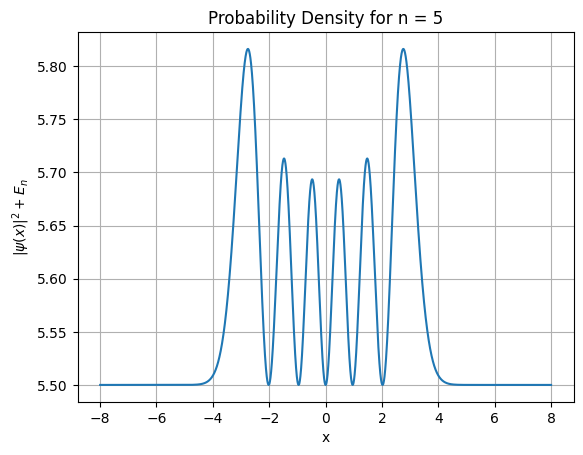

In [37]:
n_density = 5
plt.plot(x, np.abs(psi(n_density, x))**2 + n_density + 0.5)
plt.title("Probability Density for n = 5")
plt.xlabel("x")
plt.ylabel(r"$|\psi(x)|^2 + E_n$")
plt.grid(True)
plt.show()
